# 1. Building micrograd

Video: [The spelled-out intro to neural networks and backpropagation: building micrograd](https://www.youtube.com/watch?v=VMj-3S1tku0)

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
def f(x):
    return 10*x**2 - 5*x + 1

In [3]:
f(10)

951

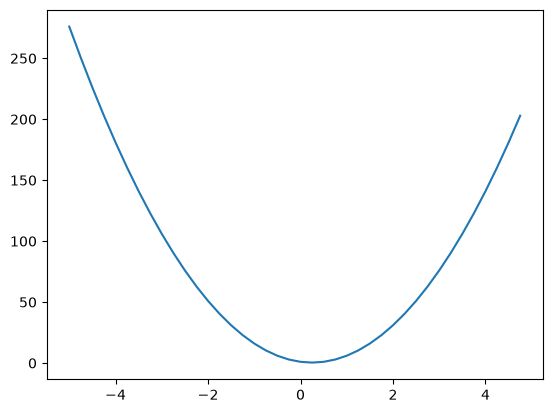

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [13]:
h = 0.00000000000000000000000000000000001
x = 3.0
(f(x+h) - f(x))/h

0.0

In [14]:
h = 0.000000000000001
x = 2.0
(f(x+h) - f(x))/h

31.974423109204505

In [15]:
h = 0.000000000000001
x = -2.0
(f(x+h) - f(x))/h

-49.737991503207006

In [16]:
# More complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [18]:
# Derivative with respect to a/b/c?
h = 0.0001

# fixing at point (a, b, c) point, a direction
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print("d1", d1)
print("d2", d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [19]:
# b direction
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print("d1", d1)
print("d2", d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [20]:
# c direction
# b direction
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print("d1", d1)
print("d2", d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


# Neural Networks

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
        
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0, label='a')
b = Value(5.0, label='b')
a + b

In [60]:
a*b

Value(data=10.0)

In [ ]:
c = Value(1, label='c')
d = a*b + c; d.label = 'd'

In [62]:
d._prev

{Value(data=1), Value(data=10.0)}

In [63]:
d._op

'+'

In [ ]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f }" % (n.label, n.data), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [3]:
draw_dot(d)

NameError: name 'draw_dot' is not defined

In [66]:
f = Value(-2.0, label='f')
L = d * f
L

Value(data=-22.0)